# EC143 Final Project — Quantile-Regression Test of Volume Contraction in Qullamaggie Breakouts

*Author:* Evan Maus  
*Course:* Ec143, Spring 2026  
*Due:* May 14, 2026

_Abstract: [TODO — 4–6 sentences. State the question, the empirical strategy on 5,286 breakout setups 2010–2025, the headline result on the pre-registered training window, and the verdict.]_

## §1 Introduction

[TODO — research question, motivation, why a quantile regression test rather than OLS, what the answer would mean for the underlying trading framework.]

## §2 Data

[TODO — daily OHLCV bars from the breakoutStudyTool / Polygon pipeline; FF3+UMD daily factors from Ken French; SPY from yfinance; yfinance ticker types for the security-type filter; sample period 2010–2025.]

In [1]:
"""Notebook setup. Run this cell first; all other code cells assume `REPO` / `DATA` are defined."""
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display

# Resolve the repo root from wherever the notebook was launched.
REPO = Path.cwd()
if not (REPO / "data" / "interim").exists():
    if (REPO.parent / "data" / "interim").exists():
        REPO = REPO.parent
    else:
        raise FileNotFoundError(f"Cannot find data/interim/ from {REPO}")

DATA    = REPO / "data" / "interim"
FACTORS = REPO / "data" / "factors"

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(200)
pd.set_option("display.precision", 4)

print(f"REPO = {REPO}")
print(f"DATA = {DATA}")

REPO = C:\Users\evanm\Documents\courses\econ143\ec143-project
DATA = C:\Users\evanm\Documents\courses\econ143\ec143-project\data\interim


In [2]:
setups = pl.read_parquet(DATA / "setups_with_residuals.parquet")
print(f"Final analysis panel: {setups.height:,} setup-rows")
print(f"Unique tickers:       {setups['ticker'].n_unique():,}")
print(f"Date range:           {setups['date'].min()} → {setups['date'].max()}")
print()
setups.group_by("universe_variant").agg(pl.len().alias("n")).sort("universe_variant")

Final analysis panel: 5,286 setup-rows
Unique tickers:       1,279
Date range:           2010-03-24 → 2025-12-24



universe_variant,n
str,u32
"""loose""",3073
"""strict""",2213


## §3 Methods

[TODO — paragraph per pipeline stage. Modules listed below for traceability; full implementations live in `src/`.]

| Stage | Module | What it does |
|---|---|---|
| M0 | `src/m0_audit.py` | survivorship + bad-bar audit on the daily-bar source |
| M1 | `src/m1_universe.py` | universe filter + 6-stage Qullamaggie consolidation-breakout detector |
| M2 | `src/m2_features.py` | per-setup features: vol_contraction_ratio, adr_pct, base_duration_days, rs_slope_vs_spy, sector |
| M3 | `src/m3_factors.py` | FF3+UMD daily factor panel + 20-day-forward residualization on the 2010–2017 training window |
| M4 | `src/m4_estimation.py` | OLS + QR(τ ∈ {0.10, 0.25, 0.50, 0.75, 0.90}) on training |
| M5 | `src/m5_walkforward.py` | expanding-window OOS sign-consistency, 2018–2025 |
| M6 | `src/m6_bootstrap.py` | stationary block bootstrap CI + placebo (mean block length 30, B=1000) |

## §4 Descriptive statistics

[TODO — short paragraph framing the three displays below: setup activity over time, distribution of the four candidate covariates, and the sector composition of the panel.]

In [3]:
# Setup counts by calendar year and universe variant.
(
    setups.with_columns(pl.col("date").dt.year().alias("year"))
          .group_by(["year", "universe_variant"]).agg(pl.len().alias("n"))
          .pivot(values="n", index="year", on="universe_variant")
          .fill_null(0)
          .sort("year")
)

year,strict,loose
i32,u32,u32
2010,89,116
2011,94,122
2012,70,96
2013,112,138
2014,87,101
2015,74,94
2016,64,84
2017,136,174
2018,124,149


In [4]:
# Distribution summary of the four candidate covariates by universe variant.
RHS = ["vol_contraction_ratio_w", "adr_pct", "base_duration_days", "rs_slope_vs_spy"]
rows = []
for v in ("loose", "strict"):
    s = setups.filter(pl.col("universe_variant") == v).select(RHS)
    for col in RHS:
        x = s[col]
        rows.append({
            "variant": v, "feature": col,
            "mean":   float(x.mean()),
            "std":    float(x.std()),
            "p10":    float(x.quantile(0.10)),
            "median": float(x.median()),
            "p90":    float(x.quantile(0.90)),
        })
pl.DataFrame(rows)

variant,feature,mean,std,p10,median,p90
str,str,f64,f64,f64,f64,f64
"""loose""","""vol_contraction_ratio_w""",1.015272,0.375834,0.633849,0.944664,1.471525
"""loose""","""adr_pct""",0.041491,0.014688,0.027656,0.037422,0.060033
"""loose""","""base_duration_days""",22.555809,7.480893,15.0,20.0,35.0
"""loose""","""rs_slope_vs_spy""",0.000748,0.004146,-0.003738,0.000384,0.005784
"""strict""","""vol_contraction_ratio_w""",1.022762,0.387345,0.633849,0.942481,1.502001
"""strict""","""adr_pct""",0.04281,0.015021,0.028209,0.038736,0.062218
"""strict""","""base_duration_days""",22.198373,7.284763,15.0,20.0,34.0
"""strict""","""rs_slope_vs_spy""",0.000842,0.004274,-0.003822,0.00043,0.006131


In [5]:
# Sector composition: counts by variant.
(
    setups.group_by(["sector", "universe_variant"]).agg(pl.len().alias("n"))
          .pivot(values="n", index="sector", on="universe_variant")
          .fill_null(0)
          .with_columns((pl.col("loose") + pl.col("strict")).alias("total"))
          .sort("total", descending=True)
)

sector,strict,loose,total
str,u32,u32,u32
"""Healthcare""",513,677,1190
"""Technology""",445,627,1072
"""Consumer Cyclical""",265,404,669
"""Industrials""",267,372,639
"""Unknown""",196,265,461
"""Financial Services""",131,170,301
"""Energy""",129,159,288
"""Basic Materials""",95,142,237
"""Communication Services""",77,123,200


## §5 Empirical specification

[TODO — explain the residualize-then-QR design. The LHS is `fwd_ret_20d_resid` with FF3+UMD factor exposures, sector FE and year FE absorbed in M3. The RHS in this stage is just the four candidate covariates: `vol_contraction_ratio_w + adr_pct + base_duration_days + rs_slope_vs_spy`. Discuss the half-split rule for vol_contraction_ratio (locked design decision), why winsorize at training-window p99, why the loose universe is the headline.]

## §6 Pre-Registered Hypothesis (locked May 3, 2026)

We pre-register a one-sided test of whether the volume contraction ratio shifts the τ=0.90 conditional quantile of factor-residualized 20-day forward returns more than it shifts the τ=0.50 conditional quantile, after controlling for the 12-1 momentum factor, sector fixed effects, and year fixed effects. The test statistic is β(0.90) − β(0.50), estimated on the 2010–2017 training period. Inference uses a stationary block bootstrap with mean block length 30. The hypothesis survives if (a) the 95% bootstrap CI of the statistic excludes zero with the predicted sign, and (b) the same sign holds in at least five of eight expanding-window OOS years (2018–2025). The headline test runs on the **loose** universe (mom_pct ≥ 0.80) to maximize sample size for quantile regression; the **strict** universe (mom_pct ≥ 0.90 plus the 15%-of-52w-high gate) is reported in §7.1 as a sensitivity analysis.

## §7 Results

[TODO — headline. State θ̂, 95% bootstrap CI, one-sided p, placebo percentile of θ̂. Sentence on what fails, sentence on what to make of it.]

In [6]:
# Loose + strict primary-spec coefficient tables (OLS row + 5 QR rows).
m4 = pl.read_parquet(DATA / "m4_results.parquet")

TAUS = (0.10, 0.25, 0.50, 0.75, 0.90)
TERMS = ["const", "vol_contraction_ratio_w", "adr_pct",
         "base_duration_days", "rs_slope_vs_spy"]

def m4_panel_table(panel: str) -> pd.DataFrame:
    df = m4.filter((pl.col("panel") == panel) & (pl.col("spec") == "primary"))
    rows = []
    spec_rows = [("OLS", "OLS", None)] + [(f"τ={t:.2f}", "QR", t) for t in TAUS]
    for label, model, tau in spec_rows:
        sub = df.filter(pl.col("model") == model)
        if tau is not None:
            sub = sub.filter(pl.col("tau") == tau)
        row = {"model/τ": label}
        for term in TERMS:
            r = sub.filter(pl.col("term") == term)
            row[term] = (
                f"{float(r['coef'][0]):+.4f} ({float(r['t_or_z'][0]):+.2f})"
                if not r.is_empty() else "—"
            )
        if not sub.is_empty():
            row["n"] = f"{int(sub['n'][0]):,}"
            row["R²/pseudo-R²"] = (
                f"{float(sub['rsquared'][0]):.4f}" if model == "OLS"
                else f"{float(sub['pseudo_r2'][0]):.4f}"
            )
        rows.append(row)
    return pd.DataFrame(rows)

print("Loose panel — primary spec")
display(m4_panel_table("loose"))
print("\nStrict panel — primary spec")
display(m4_panel_table("strict"))

Loose panel — primary spec


,model/τ,const,vol_contraction_ratio_w,adr_pct,base_duration_days,rs_slope_vs_spy,n,R²/pseudo-R²
0,OLS,+0.0742 (+3.11),-0.0066 (-0.59),-1.7511 (-4.38),-0.0000 (-0.05),-0.1997 (-0.16),925,0.0225
1,τ=0.10,+0.0612 (+2.12),-0.0235 (-1.60),-5.1747 (-10.16),+0.0007 (+0.95),+3.8956 (+2.80),925,0.1052
2,τ=0.25,+0.0623 (+2.51),-0.0124 (-1.08),-3.3174 (-8.13),+0.0002 (+0.26),-0.4099 (-0.34),925,0.0642
3,τ=0.50,+0.0622 (+2.80),+0.0026 (+0.25),-2.0743 (-5.58),+0.0003 (+0.48),+0.2170 (+0.18),925,0.0174
4,τ=0.75,+0.0638 (+2.72),+0.0106 (+0.96),-0.3946 (-0.97),+0.0001 (+0.23),-0.1827 (-0.15),925,0.0014
5,τ=0.90,+0.0582 (+1.66),-0.0019 (-0.11),+2.6284 (+4.62),-0.0005 (-0.53),-0.0150 (-0.01),925,0.0175



Strict panel — primary spec


,model/τ,const,vol_contraction_ratio_w,adr_pct,base_duration_days,rs_slope_vs_spy,n,R²/pseudo-R²
0,OLS,+0.0583 (+2.07),-0.0025 (-0.19),-1.6545 (-3.61),+0.0003 (+0.37),+0.0678 (+0.05),726,0.0187
1,τ=0.10,+0.0478 (+1.40),-0.0172 (-0.99),-4.8778 (-8.42),+0.0007 (+0.81),+1.1755 (+0.81),726,0.1048
2,τ=0.25,+0.0592 (+2.14),-0.0157 (-1.21),-3.2229 (-7.39),+0.0002 (+0.31),-0.2182 (-0.17),726,0.0670
3,τ=0.50,+0.0539 (+2.18),-0.0005 (-0.04),-1.9508 (-4.85),+0.0005 (+0.82),+0.7543 (+0.60),726,0.0173
4,τ=0.75,+0.0134 (+0.50),+0.0240 (+1.91),+0.2515 (+0.54),+0.0006 (+0.85),+0.6638 (+0.48),726,0.0044
5,τ=0.90,+0.0594 (+1.36),-0.0018 (-0.09),+2.4773 (+3.47),-0.0000 (-0.04),+1.6676 (+0.74),726,0.0161


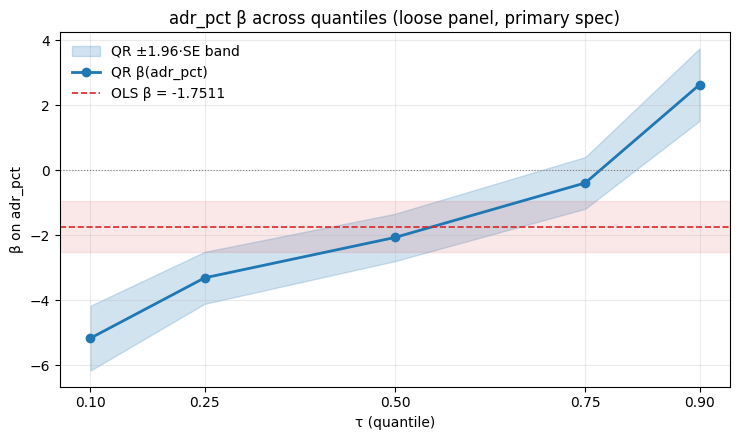

In [7]:
# Figure: adr_pct β across τ for the loose panel, with ±1.96·SE band and OLS reference.
df = m4.filter(
    (pl.col("panel") == "loose") & (pl.col("spec") == "primary")
    & (pl.col("model") == "QR") & (pl.col("term") == "adr_pct")
).sort("tau")
taus  = df["tau"].to_numpy()
coefs = df["coef"].to_numpy()
ses   = df["std_err"].to_numpy()

ols = m4.filter(
    (pl.col("panel") == "loose") & (pl.col("spec") == "primary")
    & (pl.col("model") == "OLS") & (pl.col("term") == "adr_pct")
)
ols_coef = float(ols["coef"][0]); ols_se = float(ols["std_err"][0])

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.fill_between(taus, coefs - 1.96 * ses, coefs + 1.96 * ses,
                alpha=0.20, color="C0", label="QR ±1.96·SE band")
ax.plot(taus, coefs, marker="o", color="C0", linewidth=2, label="QR β(adr_pct)")
ax.axhline(ols_coef, color="C3", linestyle="--", linewidth=1.2,
           label=f"OLS β = {ols_coef:+.4f}")
ax.axhspan(ols_coef - 1.96 * ols_se, ols_coef + 1.96 * ols_se, color="C3", alpha=0.10)
ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
ax.set_xlabel("τ (quantile)"); ax.set_ylabel("β on adr_pct")
ax.set_title("adr_pct β across quantiles (loose panel, primary spec)")
ax.set_xticks(taus); ax.legend(loc="upper left", frameon=False); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### §7.1 Strict universe (robustness)

[TODO]

In [8]:
# M5 walk-forward yearly point estimates.
m5 = pl.read_parquet(DATA / "m5_oos_results.parquet")

def m5_panel_table(panel: str):
    return (
        m5.filter(pl.col("panel") == panel).sort("year")
          .select("year", "train_end", "n_train",
                  "beta_50", "beta_90", "diff", "sign_diff")
    )

print("Loose panel — expanding-window OOS")
display(m5_panel_table("loose"))
print("\nStrict panel — expanding-window OOS")
display(m5_panel_table("strict"))

Loose panel — expanding-window OOS


year,train_end,n_train,beta_50,beta_90,diff,sign_diff
i64,date,i64,f64,f64,f64,str
2018,2017-12-31,925,0.002587,-0.001947,-0.004533,"""negative"""
2019,2018-12-31,1074,0.000647,0.009503,0.008856,"""positive"""
2020,2019-12-31,1229,0.003206,-0.005099,-0.008304,"""negative"""
2021,2020-12-31,1556,0.010201,-0.008888,-0.019089,"""negative"""
2022,2021-12-31,1970,0.00569,-0.006775,-0.012465,"""negative"""
2023,2022-12-31,2110,0.00918,-0.005001,-0.014181,"""negative"""
2024,2023-12-31,2330,0.01099,-0.00654,-0.01753,"""negative"""
2025,2024-12-31,2692,0.012395,-0.008582,-0.020977,"""negative"""



Strict panel — expanding-window OOS


year,train_end,n_train,beta_50,beta_90,diff,sign_diff
i64,date,i64,f64,f64,f64,str
2018,2017-12-31,726,-0.000513,-0.001797,-0.001284,"""negative"""
2019,2018-12-31,850,-0.004078,0.017087,0.021165,"""positive"""
2020,2019-12-31,980,-0.001491,0.004148,0.005639,"""positive"""
2021,2020-12-31,1184,0.012906,0.013203,0.000297,"""positive"""
2022,2021-12-31,1421,0.020675,0.017604,-0.003072,"""negative"""
2023,2022-12-31,1527,0.014839,0.017567,0.002728,"""positive"""
2024,2023-12-31,1693,0.026627,0.007135,-0.019492,"""negative"""
2025,2024-12-31,1939,0.023225,0.005141,-0.018084,"""negative"""


### §7.2 Expanding-window exploratory

[TODO]

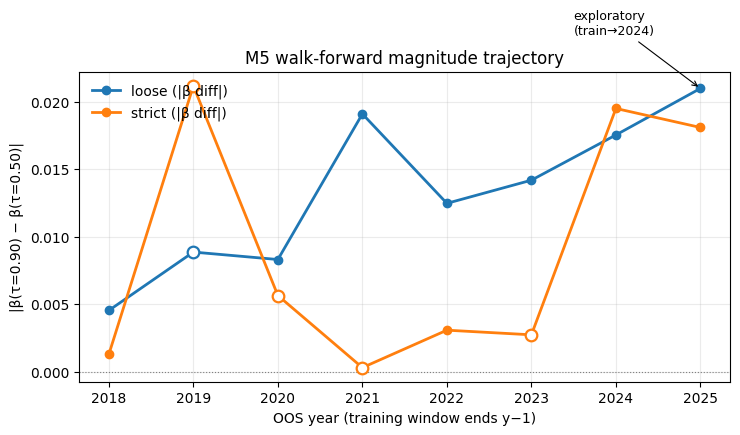

In [9]:
# Figure: |β(0.90) − β(0.50)| trajectory across expanding windows, both panels.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for panel, color in (("loose", "C0"), ("strict", "C1")):
    sub = m5.filter(pl.col("panel") == panel).sort("year")
    years = sub["year"].to_numpy()
    diffs = sub["diff"].to_numpy()
    mags  = np.abs(diffs)
    ax.plot(years, mags, marker="o", color=color, linewidth=2,
            label=f"{panel} (|β diff|)")
    # Hollow markers for sign-flip years.
    for x, d, m in zip(years, diffs, mags):
        if d >= 0:
            ax.scatter([x], [m], color="white", edgecolor=color,
                       zorder=5, s=70, linewidths=1.6)

loose_25 = m5.filter((pl.col("panel") == "loose") & (pl.col("year") == 2025))
if loose_25.height:
    x = int(loose_25["year"][0]); y = abs(float(loose_25["diff"][0]))
    ax.annotate("exploratory\n(train→2024)", xy=(x, y),
                xytext=(x - 1.5, y + 0.004), fontsize=9,
                arrowprops=dict(arrowstyle="->", color="black", lw=0.8))

ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
ax.set_xlabel("OOS year (training window ends y−1)")
ax.set_ylabel("|β(τ=0.90) − β(τ=0.50)|")
ax.set_title("M5 walk-forward magnitude trajectory")
ax.set_xticks(sorted(set(int(yy) for yy in m5["year"].to_list())))
ax.legend(loc="upper left", frameon=False); ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [10]:
# M6 bootstrap inference: percentile/basic CI, one-sided p̂, placebo summary.
m6 = pl.read_parquet(DATA / "m6_bootstrap.parquet")

def m6_summary_row(label: str, panel: str) -> dict:
    sub   = m6.filter((pl.col("label") == label) & (pl.col("panel") == panel))
    point = sub.filter(pl.col("mode") == "point")
    real  = sub.filter(pl.col("mode") == "real")["diff"].to_numpy()
    plac  = sub.filter(pl.col("mode") == "placebo")["diff"].to_numpy()
    theta = float(point["diff"][0])
    p25   = float(np.quantile(real, 0.025))
    p975  = float(np.quantile(real, 0.975))
    p_one = float((np.sum(real >= 0) + 1) / (real.size + 1))
    if plac.size:
        plac_mean = float(plac.mean())
        plac_std  = float(plac.std(ddof=1))
        pct_null  = float((plac <= theta).mean())
    else:
        plac_mean = plac_std = pct_null = float("nan")
    return {
        "panel": f"{label}/{panel}",
        "n_train": int(point["n_train"][0]),
        "θ̂":       theta,
        "CI_lo":   p25,
        "CI_hi":   p975,
        "basic_lo": 2 * theta - p975,
        "basic_hi": 2 * theta - p25,
        "one_sided_p̂":   p_one,
        "placebo_mean":  plac_mean,
        "placebo_std":   plac_std,
        "pct_null≤θ̂":   pct_null,
    }

pd.DataFrame([
    m6_summary_row("canonical", "loose"),
    m6_summary_row("canonical", "strict"),
    m6_summary_row("exploratory", "loose"),
])

,panel,n_train,θ̂,CI_lo,CI_hi,basic_lo,basic_hi,one_sided_p̂,placebo_mean,placebo_std,pct_null≤θ̂
0,canonical/loose,925,-0.0045,-0.0378,0.0425,-0.0515,0.0287,0.4955,0.0002,0.0163,0.3868
1,canonical/strict,726,-0.0013,-0.0329,0.0543,-0.0569,0.0303,0.5785,-0.0010,0.0201,0.4858
2,exploratory/loose,2692,-0.0210,-0.0507,0.0003,-0.0423,0.0088,0.0293,NaN,NaN,NaN


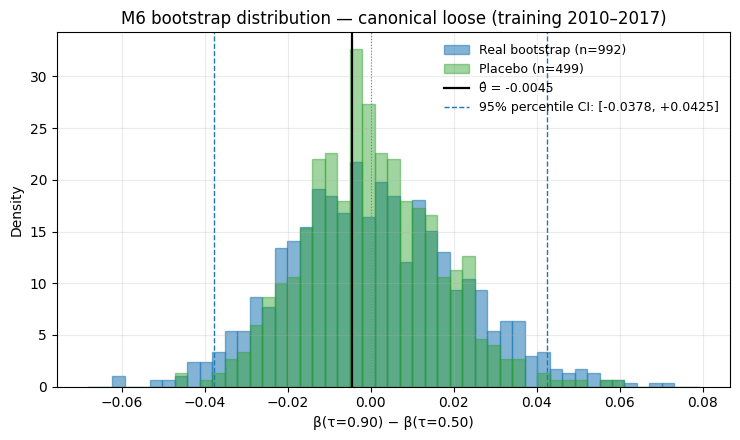

In [11]:
# Figure: canonical-loose bootstrap distribution overlaid with the placebo null.
sub = m6.filter((pl.col("label") == "canonical") & (pl.col("panel") == "loose"))
real_arr = sub.filter(pl.col("mode") == "real")["diff"].to_numpy()
plac_arr = sub.filter(pl.col("mode") == "placebo")["diff"].to_numpy()
theta    = float(sub.filter(pl.col("mode") == "point")["diff"][0])
p25  = float(np.quantile(real_arr, 0.025))
p975 = float(np.quantile(real_arr, 0.975))

lo = float(min(real_arr.min(), plac_arr.min(), theta))
hi = float(max(real_arr.max(), plac_arr.max(), theta))
pad = 0.05 * (hi - lo) if hi > lo else 0.01
bins = np.linspace(lo - pad, hi + pad, 50)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(real_arr, bins=bins, density=True, alpha=0.55, color="C0",
        label=f"Real bootstrap (n={real_arr.size:,})", edgecolor="C0")
ax.hist(plac_arr, bins=bins, density=True, alpha=0.45, color="C2",
        label=f"Placebo (n={plac_arr.size:,})", edgecolor="C2")
ax.axvline(theta, color="black", linewidth=1.6, label=f"θ̂ = {theta:+.4f}")
ax.axvline(p25,  color="C0", linestyle="--", linewidth=1.0,
           label=f"95% percentile CI: [{p25:+.4f}, {p975:+.4f}]")
ax.axvline(p975, color="C0", linestyle="--", linewidth=1.0)
ax.axvline(0, color="grey", linestyle=":", linewidth=0.8)
ax.set_xlabel("β(τ=0.90) − β(τ=0.50)")
ax.set_ylabel("Density")
ax.set_title("M6 bootstrap distribution — canonical loose (training 2010–2017)")
ax.legend(loc="upper right", frameon=False, fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### §7.3 adr_pct ancillary finding

[TODO]

## §8 Limitations

[TODO]

## §9 References & data sources

[TODO]